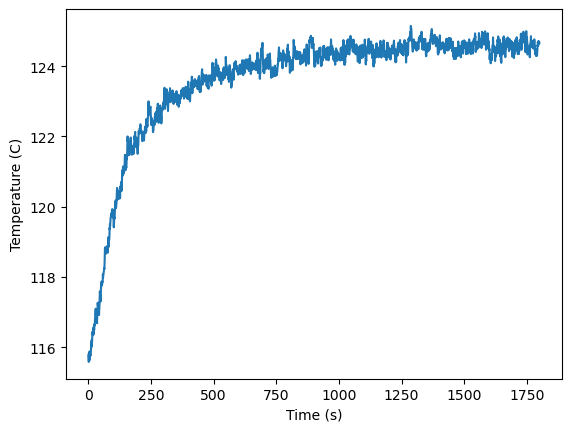

In [6]:
#Keithley 2110 Controller
import pyvisa
import matplotlib.pyplot as plt
import pandas as pd
import time

mm = pyvisa.ResourceManager().open_resource("USB0::0x05E6::0x2110::8020860::INSTR")
mm.write(":SENSe:FUNCtion 'TCOuple'")
timeList = []
tempList = []
startTime = time.time()
Tset = 130 #degC

while (time.time()-startTime) < 60*30: #seconds
    mm.write("INITiate")
    temp = float(mm.query(":FETCh?"))
    tempList.append(temp)
    timeList.append(float(time.time()-startTime))
    time.sleep(0.5)

fig, ax = plt.subplots()
ax.set_xlabel('Time (s)')
ax.set_ylabel('Temperature (C)')
ax.plot(timeList,tempList)
plt.show()
dt = pd.DataFrame(tempList,timeList)
dt.to_csv('C:\\Users\\pmlbl\\OneDrive\\Documents\\PythonScripts\\Data\\20241216\\D00\\Tset{}C.csv'.format(Tset),header=False)
fig.savefig('C:\\Users\\pmlbl\\OneDrive\\Documents\\PythonScripts\\Data\\20241216\\D00\\Tset{}C.png'.format(Tset))
mm.close()